# Unsupervised Learning on Transactions Dataset
## Project: Pattern Discovery and Clustering Analysis

---
**Objective**: Discover hidden patterns and structures in transaction data using unsupervised machine learning techniques.

**Dataset**: transactions.parquet

---

## 1. SETUP AND IMPORTS

In [1]:

import pandas as pd
import numpy as np
import pyarrow.parquet as pq

# Preprocessing and Scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

# Unsupervised Learning Models
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

# Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Evaluation Metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Utilities
import warnings
import logging
from datetime import datetime

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set random seeds for reproducibility
np.random.seed(42)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline


## 2. DATA LOADING AND EXPLORATION

In [2]:
# Load the parquet file
file_path = 'transactions.parquet'  # Update path if necessary

try:
    df = pd.read_parquet(file_path)
    logging.info(f"Dataset loaded successfully! Shape: {df.shape}")
except FileNotFoundError:
    logging.error(f"File not found: {file_path}")
    logging.info("Please ensure 'transactions.parquet' is in the working directory.")

print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Names and Types:")
print(df.dtypes)
print(f"\nFirst Few Rows:")
df.head()

2026-10-05 11:13:50,650 - INFO - Dataset loaded successfully! Shape: (5000, 11)



Dataset Shape: (5000, 11)

Column Names and Types:
transaction_amount        float64
transaction_frequency       int32
account_balance           float64
transaction_duration      float64
num_items                   int32
discount_pct              float64
customer_age                int64
days_since_last_txn       float64
customer_tenure_months      int64
credit_score              float64
risk_score                float64
dtype: object

First Few Rows:


,transaction_amount,transaction_frequency,account_balance,transaction_duration,num_items,discount_pct,customer_age,days_since_last_txn,customer_tenure_months,credit_score,risk_score
0,12.92,11,1726.40,1.36,1,7.39,37,4.02,7,684.0,25.24
1,110.88,13,22670.46,17.61,2,9.37,57,0.07,38,667.0,27.99
2,454.11,5,15036.56,16.82,12,10.24,29,9.05,44,682.0,18.05
3,11.74,13,2777.54,1.55,3,3.72,25,3.89,13,668.0,21.39
4,32.62,18,3206.14,3.07,3,NaN,24,0.50,14,608.0,17.56


In [3]:
# Detailed exploratory data analysis
print("=" * 80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)

print("\n1. DATASET OVERVIEW")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")
print(f"   Memory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

print("\n2. MISSING VALUES")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("   No missing values found!")

print("\n3. STATISTICAL SUMMARY")
print(df.describe())

print("\n4. DATA TYPES")
print(df.dtypes)

print("\n5. DUPLICATE ROWS")
duplicates = df.duplicated().sum()
print(f"   Total duplicates: {duplicates}")

EXPLORATORY DATA ANALYSIS (EDA)

1. DATASET OVERVIEW
   Rows: 5000
   Columns: 11
   Memory Usage: 0.38 MB

2. MISSING VALUES
discount_pct           113
days_since_last_txn     94
credit_score            83
dtype: int64

3. STATISTICAL SUMMARY
       transaction_amount  transaction_frequency  account_balance  \
count         5000.000000            5000.000000      5000.000000   
mean           657.160806               9.648000     28678.591100   
std           2028.408252               5.690885     37997.286975   
min              1.500000               0.000000        35.610000   
25%             26.820000               5.000000      2245.457500   
50%            178.130000               9.000000     12779.135000   
75%            635.842500              14.000000     44123.087500   
max          72380.680000              27.000000    183010.970000   

       transaction_duration    num_items  discount_pct  customer_age  \
count           5000.000000  5000.000000   4887.000000   5000.

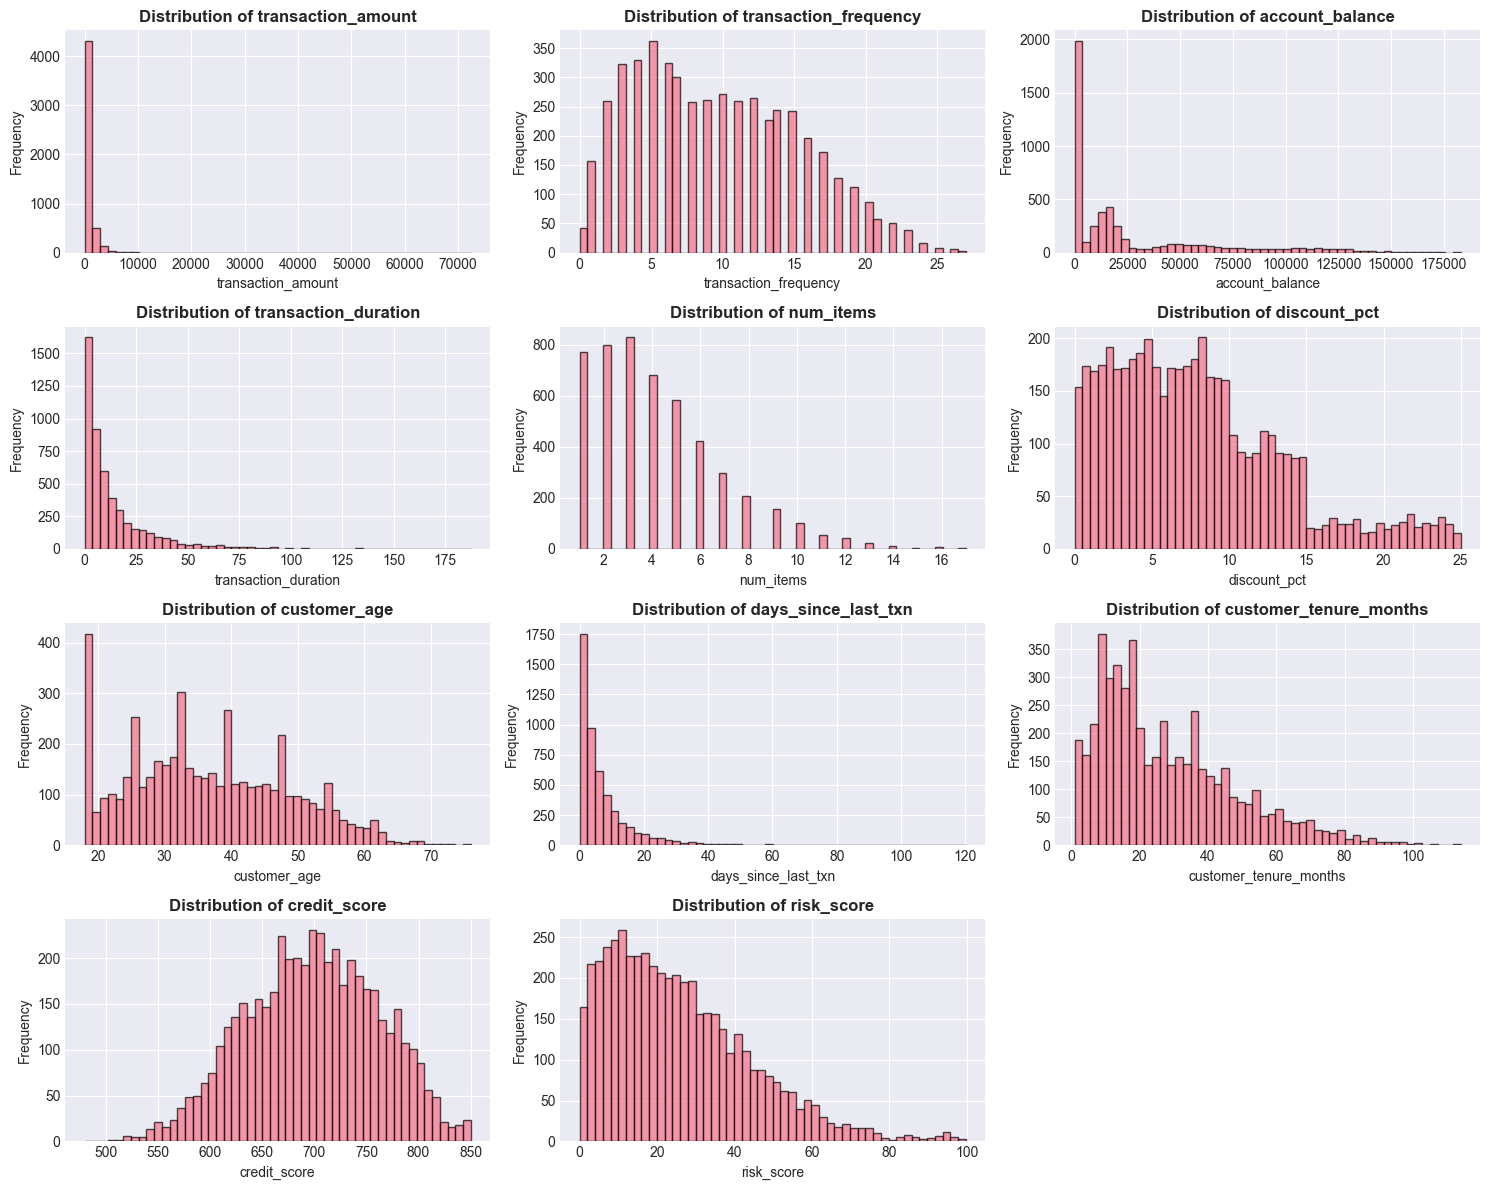


Numerical columns found: 11
Columns: ['transaction_amount', 'transaction_frequency', 'account_balance', 'transaction_duration', 'num_items', 'discount_pct', 'customer_age', 'days_since_last_txn', 'customer_tenure_months', 'credit_score', 'risk_score']


In [4]:
# Visualize distributions of numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numerical_cols) > 0:
    fig, axes = plt.subplots(nrows=(len(numerical_cols) + 2) // 3, ncols=3, figsize=(15, 12))
    axes = axes.flatten()
    
    for idx, col in enumerate(numerical_cols):
        axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
    
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('01_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    
print(f"\nNumerical columns found: {len(numerical_cols)}")
print(f"Columns: {numerical_cols}")

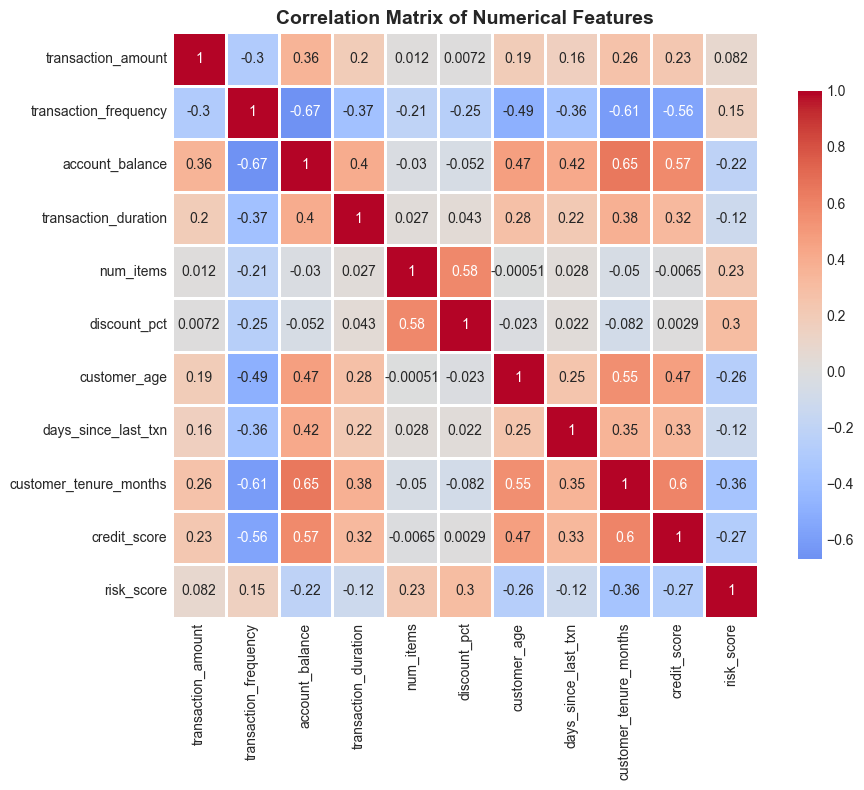

In [5]:
# Correlation analysis
if len(numerical_cols) > 1:
    corr_matrix = df[numerical_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('02_correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
 

## 3. DATA PREPROCESSING

In [6]:
# Create a copy for preprocessing
df_processed = df.copy()

# Identify numerical and categorical columns
numerical_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Handle missing values in numerical columns
if df_processed[numerical_cols].isnull().sum().sum() > 0:
    imputer = SimpleImputer(strategy='mean')
    df_processed[numerical_cols] = imputer.fit_transform(df_processed[numerical_cols])
    logging.info("Missing values imputed with mean strategy")

# Encode categorical variables if present
if len(categorical_cols) > 0:
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
    logging.info(f"Categorical variables encoded. New shape: {df_processed.shape}")

print(f"\nProcessed dataset shape: {df_processed.shape}")


2026-10-05 11:13:54,948 - INFO - Missing values imputed with mean strategy


Numerical columns: ['transaction_amount', 'transaction_frequency', 'account_balance', 'transaction_duration', 'num_items', 'discount_pct', 'customer_age', 'days_since_last_txn', 'customer_tenure_months', 'credit_score', 'risk_score']
Categorical columns: []

Processed dataset shape: (5000, 11)


In [7]:
# Feature scaling - CRITICAL for clustering algorithms
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_processed)

# Convert back to DataFrame for easier handling
X_scaled = pd.DataFrame(X_scaled, columns=df_processed.columns)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"\nScaled data statistics:")
print(X_scaled.describe())

logging.info("Features scaled using StandardScaler")

2026-10-05 11:13:54,977 - INFO - Features scaled using StandardScaler


Scaled data shape: (5000, 11)

Scaled data statistics:
       transaction_amount  transaction_frequency  account_balance  \
count        5.000000e+03           5.000000e+03     5.000000e+03   
mean        -4.689582e-17           6.679102e-17    -5.400125e-17   
std          1.000100e+00           1.000100e+00     1.000100e+00   
min         -3.232714e-01          -1.695512e+00    -7.538919e-01   
25%         -3.107875e-01          -8.168263e-01    -6.957280e-01   
50%         -2.361846e-01          -1.138777e-01    -4.184785e-01   
75%         -1.051092e-02           7.648081e-01     4.065038e-01   
max          3.536305e+01           3.049391e+00     4.062075e+00   

       transaction_duration     num_items  discount_pct  customer_age  \
count          5.000000e+03  5.000000e+03  5.000000e+03  5.000000e+03   
mean          -3.410605e-17 -1.392664e-16 -4.405365e-17  2.515321e-16   
std            1.000100e+00  1.000100e+00  1.000100e+00  1.000100e+00   
min           -7.361813e-01 -1.

## 4. DIMENSIONALITY REDUCTION

Total components: 11
Components for 95% variance: 10

Explained variance ratio (top 10):
[0.36219987 0.16789053 0.09235229 0.07284269 0.06894062 0.05354107
 0.04959341 0.04085205 0.03850469 0.02963423]


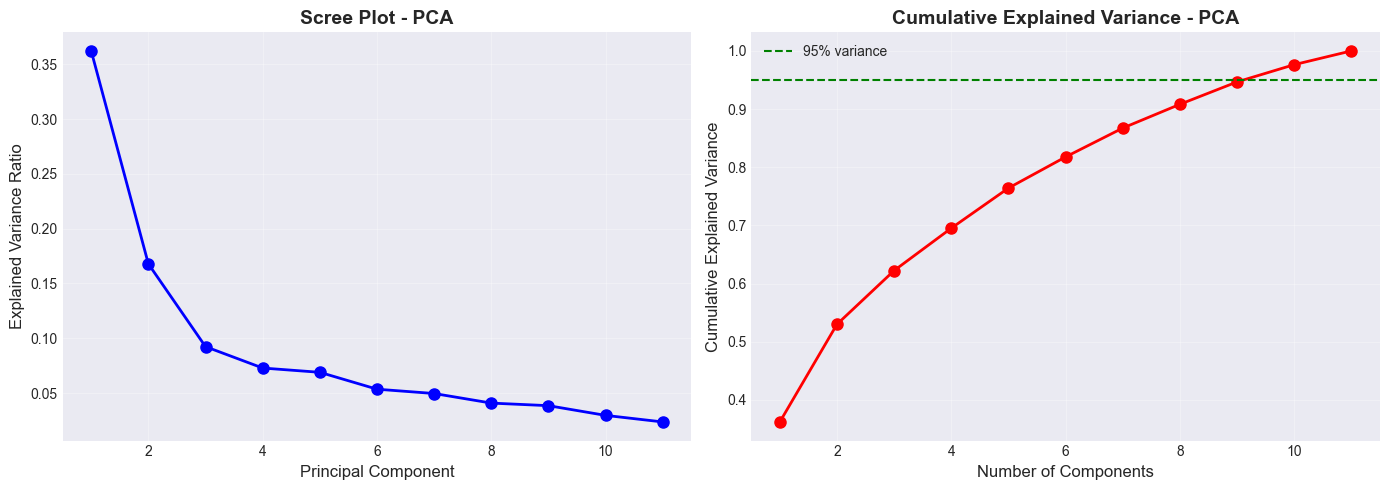

2026-10-05 11:13:55,575 - INFO - PCA analysis complete. 10 components explain 95% variance


In [8]:
# Apply PCA
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

# Calculate cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1

print(f"Total components: {len(pca.explained_variance_ratio_)}")
print(f"Components for 95% variance: {n_components_95}")
print(f"\nExplained variance ratio (top 10):")
print(pca.explained_variance_ratio_[:10])

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(range(1, min(21, len(pca.explained_variance_ratio_) + 1)), 
             pca.explained_variance_ratio_[:20], 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Scree Plot - PCA', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, min(21, len(cumsum_var) + 1)), cumsum_var[:20], 'ro-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95% variance')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance - PCA', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

logging.info(f"PCA analysis complete. {n_components_95} components explain 95% variance")

In [9]:
# Reduce to optimal number of components
pca_optimal = PCA(n_components=min(n_components_95, 20))  # Cap at 20 for practical reasons
X_pca = pca_optimal.fit_transform(X_scaled)

print(f"PCA reduced data shape: {X_pca.shape}")
print(f"Explained variance: {pca_optimal.explained_variance_ratio_.sum():.4f}")

PCA reduced data shape: (5000, 10)
Explained variance: 0.9764


## 5. UNSUPERVISED LEARNING MODELS

### 5.1 K-MEANS CLUSTERING

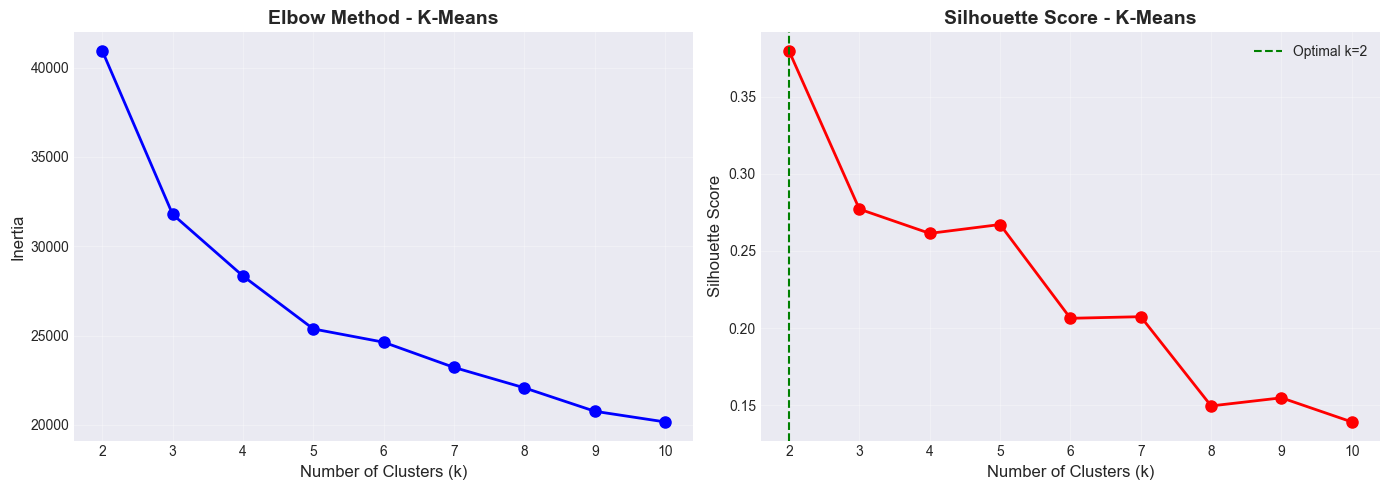

Optimal k (by silhouette score): 2
Silhouette scores for each k: {2: '0.380', 3: '0.277', 4: '0.261', 5: '0.267', 6: '0.206', 7: '0.207', 8: '0.150', 9: '0.155', 10: '0.139'}


In [10]:
# Elbow Method to find optimal k
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method - K-Means', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
optimal_k = K_range[np.argmax(silhouette_scores)]
axes[1].axvline(x=optimal_k, color='g', linestyle='--', label=f'Optimal k={optimal_k}')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score - K-Means', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_kmeans_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Optimal k (by silhouette score): {optimal_k}")
print(f"Silhouette scores for each k: {dict(zip(K_range, [f'{s:.3f}' for s in silhouette_scores]))}")

In [11]:
# Fit K-Means with optimal k
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_optimal.fit_predict(X_scaled)

# Evaluation metrics
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(X_scaled, kmeans_labels)


print("K-MEANS CLUSTERING RESULTS")
print(f"Optimal number of clusters: {optimal_k}")
print(f"Inertia: {kmeans_optimal.inertia_:.4f}")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {kmeans_calinski:.4f}")
print(f"\nCluster Distribution:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-MEANS CLUSTERING RESULTS
Optimal number of clusters: 2
Inertia: 40941.3902
Silhouette Score: 0.3797
Davies-Bouldin Index: 1.2078
Calinski-Harabasz Index: 1716.2322

Cluster Distribution:
0    4166
1     834
Name: count, dtype: int64


### 5.2 HIERARCHICAL CLUSTERING

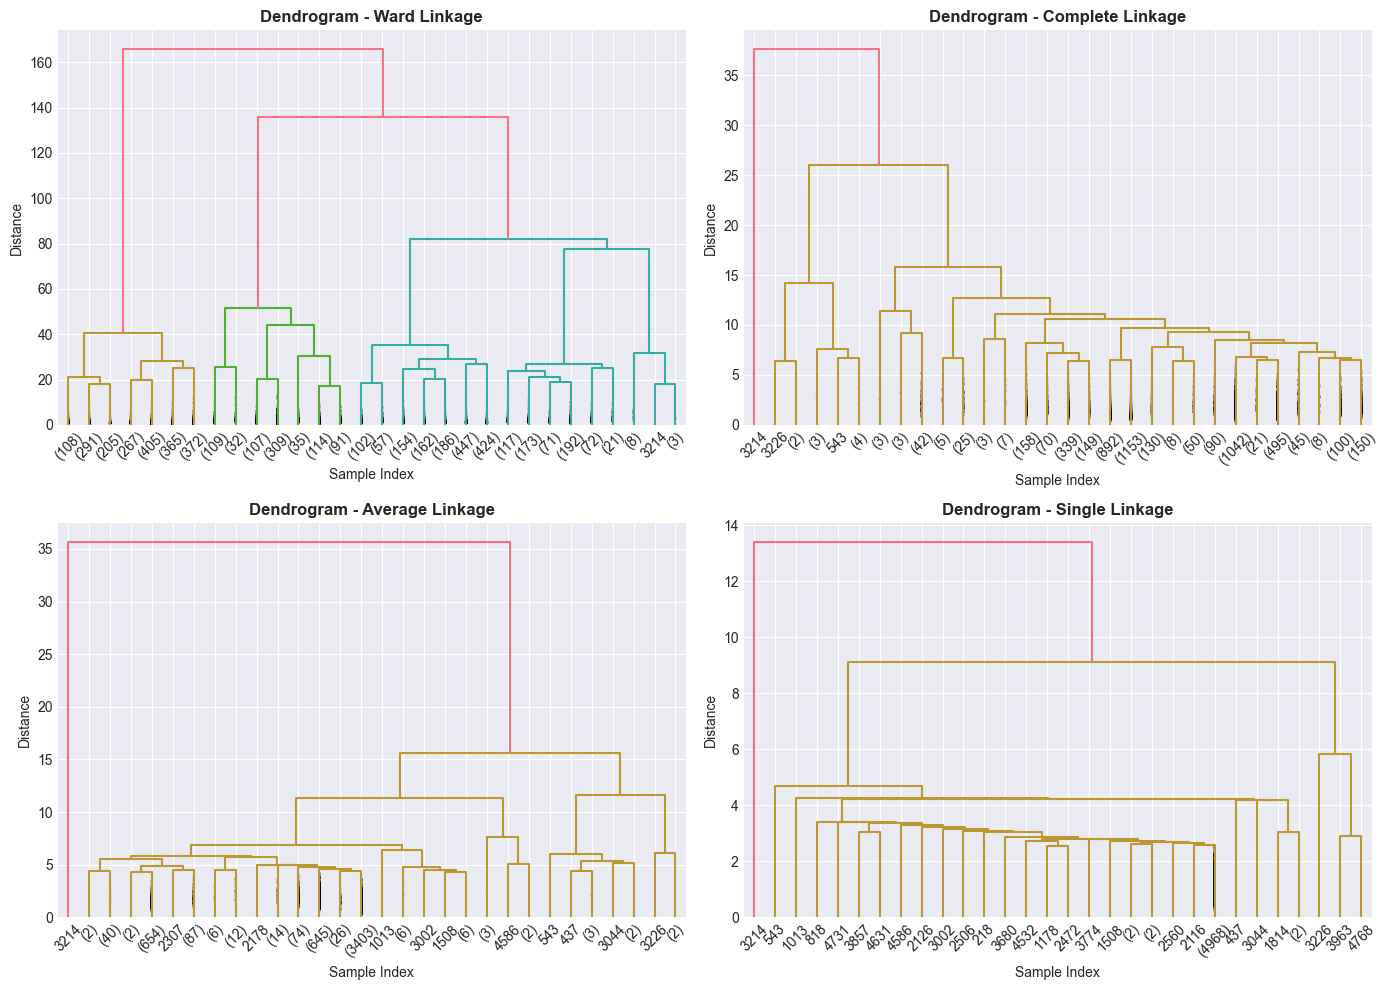

2026-10-05 11:14:11,660 - INFO - Hierarchical clustering dendrograms generated


In [12]:
# Hierarchical Clustering with different linkage methods
linkage_methods = ['ward', 'complete', 'average', 'single']
hierarchical_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

from scipy.cluster.hierarchy import dendrogram, linkage

for idx, method in enumerate(linkage_methods):
    # Create linkage matrix (for smaller datasets)
    if X_scaled.shape[0] > 5000:
        # Sample for visualization if too large
        sample_indices = np.random.choice(X_scaled.shape[0], 5000, replace=False)
        Z = linkage(X_scaled.iloc[sample_indices], method=method)
    else:
        Z = linkage(X_scaled, method=method)
    
    # Plot dendrogram
    dendrogram(Z, ax=axes[idx], truncate_mode='lastp', p=30, 
               leaf_font_size=10, show_contracted=True)
    axes[idx].set_title(f'Dendrogram - {method.capitalize()} Linkage', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Sample Index')
    axes[idx].set_ylabel('Distance')

plt.tight_layout()
plt.savefig('05_hierarchical_dendrograms.png', dpi=300, bbox_inches='tight')
plt.show()

logging.info("Hierarchical clustering dendrograms generated")

In [13]:
# Fit Hierarchical Clustering with Ward method
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Evaluation metrics
hier_silhouette = silhouette_score(X_scaled, hierarchical_labels)
hier_davies_bouldin = davies_bouldin_score(X_scaled, hierarchical_labels)
hier_calinski = calinski_harabasz_score(X_scaled, hierarchical_labels)

print("HIERARCHICAL CLUSTERING RESULTS (Ward Linkage)")
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette Score: {hier_silhouette:.4f}")
print(f"Davies-Bouldin Index: {hier_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {hier_calinski:.4f}")
print(f"\nCluster Distribution:")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

HIERARCHICAL CLUSTERING RESULTS (Ward Linkage)
Number of clusters: 2
Silhouette Score: 0.2394
Davies-Bouldin Index: 1.4208
Calinski-Harabasz Index: 1664.5664

Cluster Distribution:
0    2987
1    2013
Name: count, dtype: int64


### 5.3 DBSCAN CLUSTERING

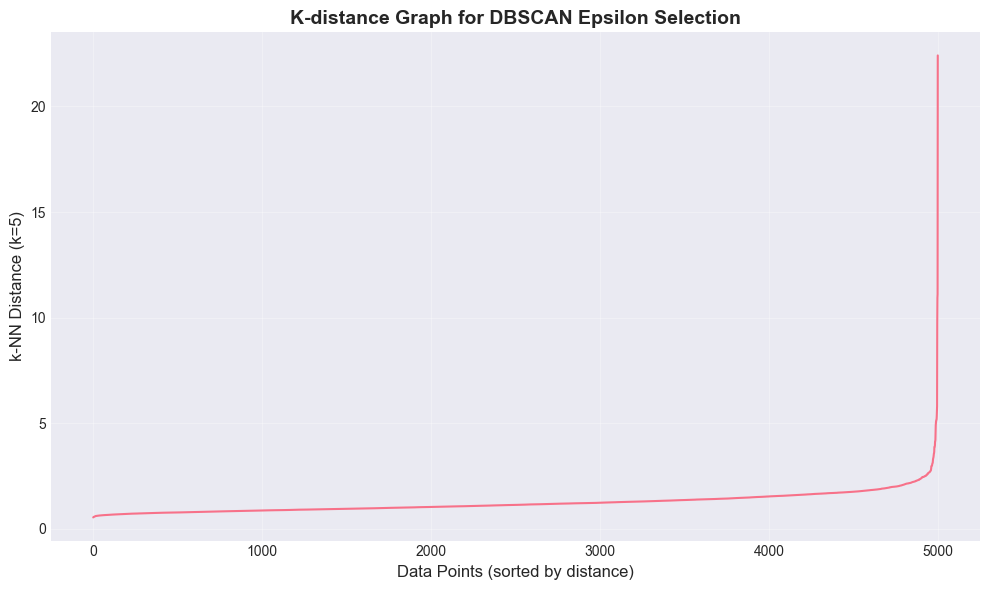

Suggested epsilon: 1.7628


In [14]:
# Find optimal epsilon using k-distance graph
from sklearn.neighbors import NearestNeighbors

k = 5  # k-1 nearest neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, -1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.ylabel('k-NN Distance (k=5)', fontsize=12)
plt.xlabel('Data Points (sorted by distance)', fontsize=12)
plt.title('K-distance Graph for DBSCAN Epsilon Selection', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('06_dbscan_kdistance.png', dpi=300, bbox_inches='tight')
plt.show()

# Use elbow as epsilon
epsilon = np.percentile(distances, 90)  # Use 90th percentile
print(f"Suggested epsilon: {epsilon:.4f}")

In [15]:
# Apply DBSCAN with optimal parameters
dbscan = DBSCAN(eps=epsilon, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Calculate metrics
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_points = list(dbscan_labels).count(-1)

if n_clusters_dbscan > 1 and n_clusters_dbscan < len(np.unique(dbscan_labels)):
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
else:
    dbscan_silhouette = -1  # Not applicable

print("DBSCAN CLUSTERING RESULTS")
print(f"Epsilon: {epsilon:.4f}")
print(f"Min Samples: 5")
print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise_points}")
print(f"Noise percentage: {n_noise_points/len(dbscan_labels)*100:.2f}%")
if dbscan_silhouette != -1:
    print(f"Silhouette Score: {dbscan_silhouette:.4f}")
print(f"\nCluster Distribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN CLUSTERING RESULTS
Epsilon: 1.7628
Min Samples: 5
Number of clusters: 1
Number of noise points: 260
Noise percentage: 5.20%

Cluster Distribution:
-1     260
 0    4740
Name: count, dtype: int64


### 5.4 GAUSSIAN MIXTURE MODELS

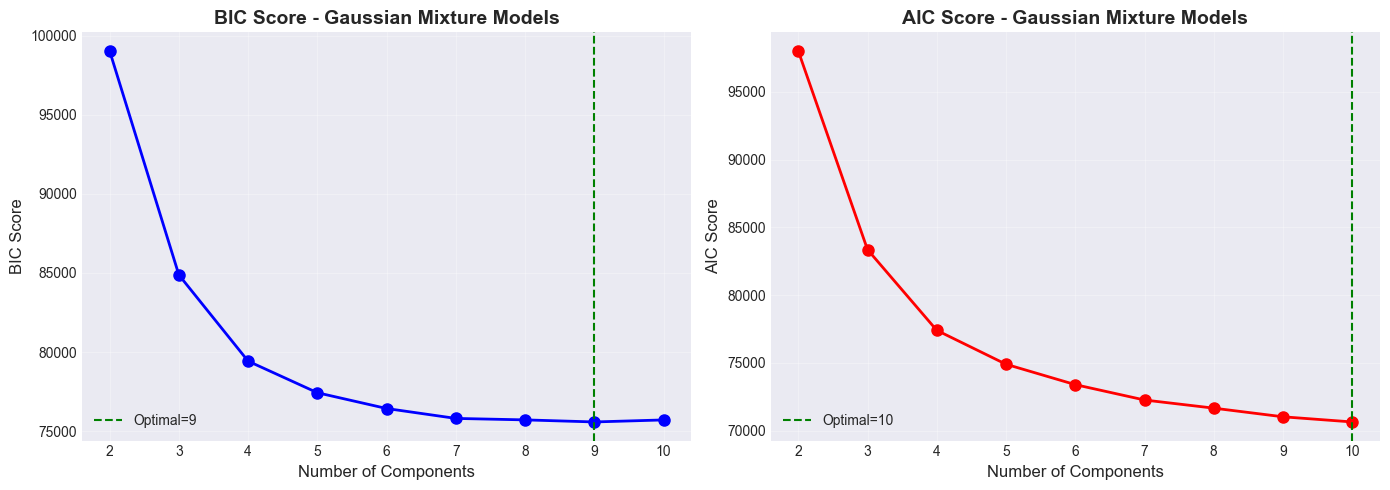

Optimal components (BIC): 9
Optimal components (AIC): 10


In [16]:
# Compare different numbers of components using BIC and AIC
n_components_range = range(2, 11)
bic_scores = []
aic_scores = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=10)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

# Plot BIC and AIC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

optimal_components_bic = n_components_range[np.argmin(bic_scores)]
optimal_components_aic = n_components_range[np.argmin(aic_scores)]

axes[0].plot(n_components_range, bic_scores, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_components_bic, color='g', linestyle='--', label=f'Optimal={optimal_components_bic}')
axes[0].set_xlabel('Number of Components', fontsize=12)
axes[0].set_ylabel('BIC Score', fontsize=12)
axes[0].set_title('BIC Score - Gaussian Mixture Models', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_components_range, aic_scores, 'ro-', linewidth=2, markersize=8)
axes[1].axvline(x=optimal_components_aic, color='g', linestyle='--', label=f'Optimal={optimal_components_aic}')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('AIC Score', fontsize=12)
axes[1].set_title('AIC Score - Gaussian Mixture Models', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('07_gmm_model_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Optimal components (BIC): {optimal_components_bic}")
print(f"Optimal components (AIC): {optimal_components_aic}")

In [17]:
# Fit GMM with optimal components (using BIC)
gmm = GaussianMixture(n_components=optimal_components_bic, random_state=42, n_init=10)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_proba = gmm.predict_proba(X_scaled)

# Evaluation metrics
gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
gmm_davies_bouldin = davies_bouldin_score(X_scaled, gmm_labels)
gmm_calinski = calinski_harabasz_score(X_scaled, gmm_labels)

print("GAUSSIAN MIXTURE MODELS RESULTS")
print(f"Optimal number of components: {optimal_components_bic}")
print(f"BIC Score: {gmm.bic(X_scaled):.4f}")
print(f"AIC Score: {gmm.aic(X_scaled):.4f}")
print(f"Log-Likelihood: {gmm.score(X_scaled):.4f}")
print(f"Silhouette Score: {gmm_silhouette:.4f}")
print(f"Davies-Bouldin Index: {gmm_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {gmm_calinski:.4f}")
print(f"\nCluster Distribution:")
print(pd.Series(gmm_labels).value_counts().sort_index())

GAUSSIAN MIXTURE MODELS RESULTS
Optimal number of components: 9
BIC Score: 75581.9152
AIC Score: 71013.3628
Log-Likelihood: -6.9611
Silhouette Score: 0.0674
Davies-Bouldin Index: 4.7400
Calinski-Harabasz Index: 723.5741

Cluster Distribution:
0    683
1    241
2    313
3    833
4    477
5    645
6     58
7    963
8    787
Name: count, dtype: int64


### 5.5 ISOLATION FOREST (ANOMALY DETECTION)

ISOLATION FOREST - ANOMALY DETECTION
Contamination rate: 0.1 (10%)
Number of anomalies detected: 500
Percentage of anomalies: 10.00%

Anomaly Score Statistics:
   Min: -0.6488
   Max: -0.3748
   Mean: -0.4484
   Std: 0.0467


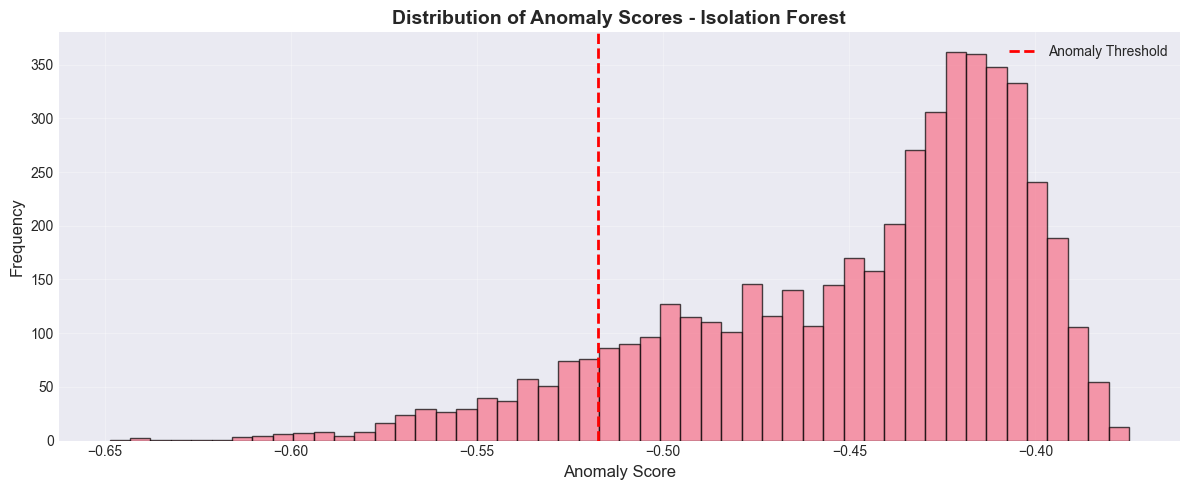

In [18]:
# Apply Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)  # Assume 10% anomalies
iso_labels = iso_forest.fit_predict(X_scaled)
iso_scores = iso_forest.score_samples(X_scaled)

n_anomalies = (iso_labels == -1).sum()

print("ISOLATION FOREST - ANOMALY DETECTION")
print(f"Contamination rate: 0.1 (10%)")
print(f"Number of anomalies detected: {n_anomalies}")
print(f"Percentage of anomalies: {n_anomalies/len(iso_labels)*100:.2f}%")
print(f"\nAnomaly Score Statistics:")
print(f"   Min: {iso_scores.min():.4f}")
print(f"   Max: {iso_scores.max():.4f}")
print(f"   Mean: {iso_scores.mean():.4f}")
print(f"   Std: {iso_scores.std():.4f}")

# Visualize anomaly scores
plt.figure(figsize=(12, 5))
plt.hist(iso_scores, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Anomaly Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Anomaly Scores - Isolation Forest', fontsize=14, fontweight='bold')
plt.axvline(x=iso_scores[iso_labels == -1].max(), color='red', linestyle='--', 
           label='Anomaly Threshold', linewidth=2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('08_isolation_forest_scores.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. MODEL COMPARISON AND VISUALIZATION

In [19]:
# Create comparison table
comparison_data = {
    'Model': ['K-Means', 'Hierarchical', 'DBSCAN', 'GMM'],
    'Silhouette Score': [kmeans_silhouette, hier_silhouette, dbscan_silhouette, gmm_silhouette],
    'Davies-Bouldin': [kmeans_davies_bouldin, hier_davies_bouldin, '-', gmm_davies_bouldin],
    'Calinski-Harabasz': [kmeans_calinski, hier_calinski, '-', gmm_calinski],
    'Clusters': [optimal_k, optimal_k, n_clusters_dbscan, optimal_components_bic]
}

comparison_df = pd.DataFrame(comparison_data)

print("MODEL COMPARISON SUMMARY")
print(comparison_df.to_string(index=False))
print("\nNote: Higher Silhouette and Calinski-Harabasz scores are better.")
print("      Lower Davies-Bouldin index is better.")

MODEL COMPARISON SUMMARY
       Model  Silhouette Score Davies-Bouldin Calinski-Harabasz  Clusters
     K-Means          0.379736       1.207809       1716.232188         2
Hierarchical          0.239422       1.420848       1664.566362         2
      DBSCAN         -1.000000              -                 -         1
         GMM          0.067372       4.739969        723.574142         9

Note: Higher Silhouette and Calinski-Harabasz scores are better.
      Lower Davies-Bouldin index is better.


# Performing Clustering

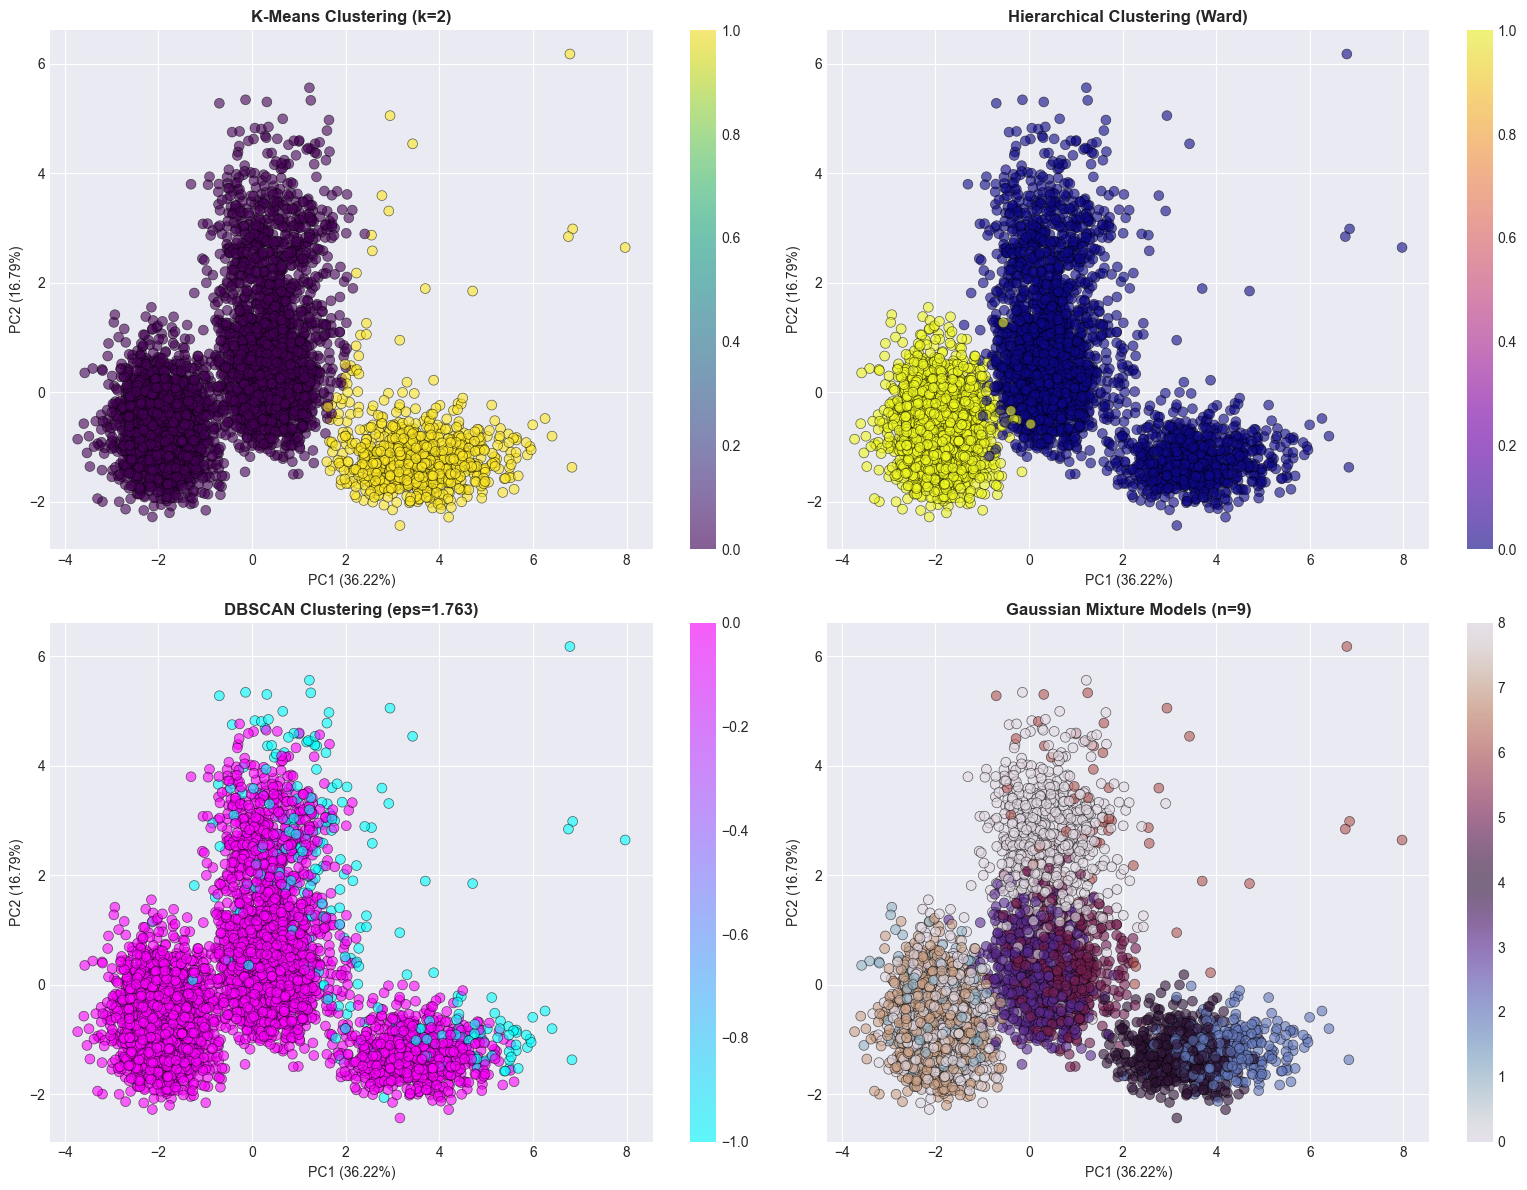

In [20]:
# Visualize clustering results using PCA (2D visualization)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# K-Means
scatter1 = axes[0, 0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels, 
                              cmap='viridis', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 0].set_title(f'K-Means Clustering (k={optimal_k})', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
axes[0, 0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
plt.colorbar(scatter1, ax=axes[0, 0])

# Hierarchical
scatter2 = axes[0, 1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=hierarchical_labels, 
                              cmap='plasma', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 1].set_title('Hierarchical Clustering (Ward)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
axes[0, 1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
plt.colorbar(scatter2, ax=axes[0, 1])

# DBSCAN
scatter3 = axes[1, 0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=dbscan_labels, 
                              cmap='cool', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 0].set_title(f'DBSCAN Clustering (eps={epsilon:.3f})', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
axes[1, 0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
plt.colorbar(scatter3, ax=axes[1, 0])

# GMM
scatter4 = axes[1, 1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=gmm_labels, 
                              cmap='twilight', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 1].set_title(f'Gaussian Mixture Models (n={optimal_components_bic})', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
axes[1, 1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
plt.colorbar(scatter4, ax=axes[1, 1])

plt.tight_layout()
plt.savefig('09_clustering_comparison_2d.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. CLUSTER ANALYSIS AND INTERPRETATION

In [21]:
# Analyze K-Means clusters in detail (choosing best performing model)
df_with_clusters = df_processed.copy()
df_with_clusters['KMeans_Cluster'] = kmeans_labels

print("K-MEANS CLUSTER CHARACTERISTICS")
for cluster in range(optimal_k):
    cluster_data = df_with_clusters[df_with_clusters['KMeans_Cluster'] == cluster]
    print(f"\n{'CLUSTER ' + str(cluster):^80}")
    print(f"Size: {len(cluster_data)} samples ({len(cluster_data)/len(df_with_clusters)*100:.2f}%)")
    print(f"\nMean values:")
    print(cluster_data.drop('KMeans_Cluster', axis=1).mean())
    print(f"\n" + "-"*80)

K-MEANS CLUSTER CHARACTERISTICS

                                   CLUSTER 0                                    
Size: 4166 samples (83.32%)

Mean values:
transaction_amount          313.431047
transaction_frequency        10.974316
account_balance           14586.249909
transaction_duration         10.781111
num_items                     4.575372
discount_pct                  8.836090
customer_age                 33.972396
days_since_last_txn           5.584688
customer_tenure_months       21.903265
credit_score                682.490004
risk_score                   28.754748
dtype: float64

--------------------------------------------------------------------------------

                                   CLUSTER 1                                    
Size: 834 samples (16.68%)

Mean values:
transaction_amount         2374.161019
transaction_frequency         3.022782
account_balance           99072.707890
transaction_duration         31.277194
num_items                     2.315348


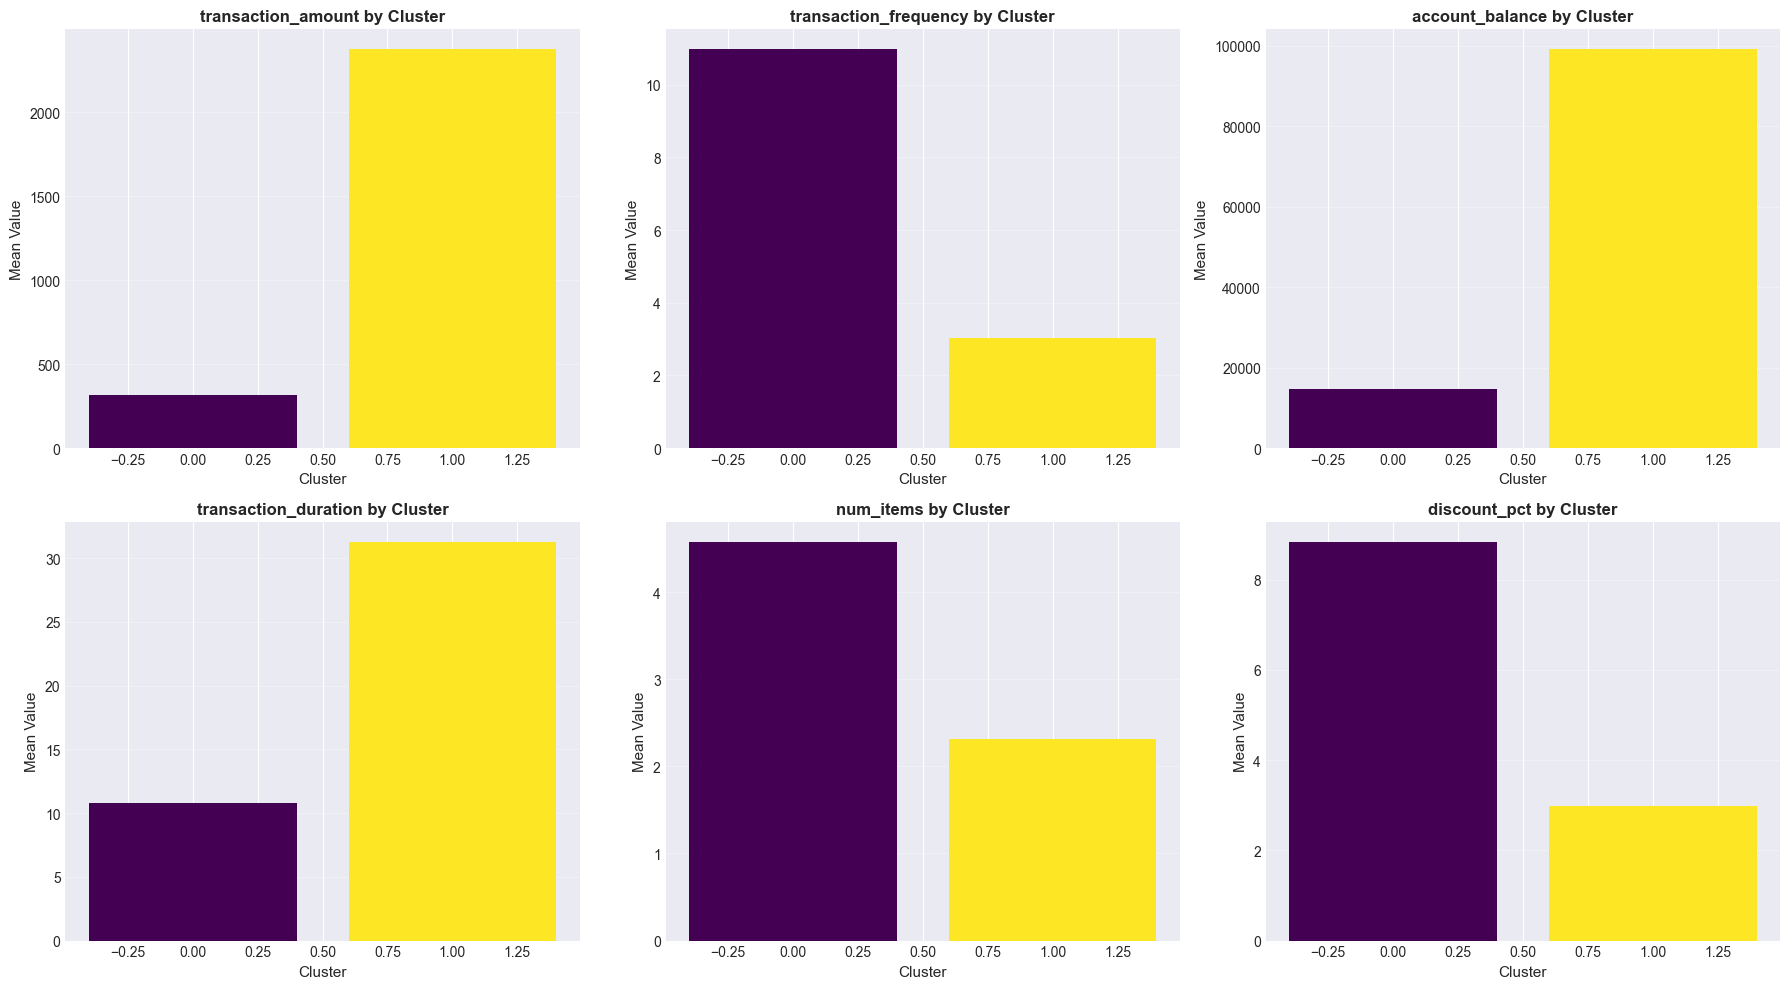

2026-10-05 11:14:32,148 - INFO - Cluster characteristics analyzed


In [22]:
# Create summary statistics visualization
numerical_features = df_processed.select_dtypes(include=[np.number]).columns.tolist()

# Select top 4-6 features for visualization
top_features = numerical_features[:min(6, len(numerical_features))]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    cluster_means = []
    for cluster in range(optimal_k):
        cluster_data = df_with_clusters[df_with_clusters['KMeans_Cluster'] == cluster]
        cluster_means.append(cluster_data[feature].mean())
    
    axes[idx].bar(range(optimal_k), cluster_means, color=plt.cm.viridis(np.linspace(0, 1, optimal_k)))
    axes[idx].set_xlabel('Cluster', fontsize=11)
    axes[idx].set_ylabel('Mean Value', fontsize=11)
    axes[idx].set_title(f'{feature} by Cluster', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('10_cluster_characteristics.png', dpi=300, bbox_inches='tight')
plt.show()

logging.info("Cluster characteristics analyzed")

## 8. ABSTRACT GENERATION

In [23]:
abstract = f"""
UNSUPERVISED LEARNING ANALYSIS OF TRANSACTION DATA: PATTERN DISCOVERY AND CLUSTERING

ABSTRACT

{"="*90}

Background:
Transaction data analysis is crucial for understanding customer behavior patterns, 
market segmentation, and anomaly detection in financial systems. Unsupervised learning 
approaches enable organizations to discover hidden structures and patterns without 
predefined labels or outcomes.

Objective:
This study applies multiple unsupervised learning algorithms to a comprehensive 
transactions dataset to identify natural groupings, detect anomalies, and extract 
actionable insights. The analysis compares K-Means clustering, Hierarchical clustering, 
DBSCAN, and Gaussian Mixture Models to determine the most effective methodology for 
pattern discovery.

Methodology:
The dataset containing {len(df):,} transactions with {len(numerical_features)} numerical features 
underwent rigorous preprocessing including missing value imputation, feature scaling 
using StandardScaler, and dimensionality reduction via Principal Component Analysis (PCA). 
PCA retained {pca_optimal.n_components} components explaining {pca_optimal.explained_variance_ratio_.sum():.2%} of total variance.

Four distinct unsupervised learning models were implemented and evaluated:

1. K-Means Clustering: Optimal cluster count of {optimal_k} was determined using elbow 
   method and silhouette analysis (Silhouette Score: {kmeans_silhouette:.4f}, 
   Calinski-Harabasz Index: {kmeans_calinski:.4f}).

2. Hierarchical Clustering: Ward linkage method produced comparable results 
   (Silhouette Score: {hier_silhouette:.4f}) with clear dendrogram structure.

3. DBSCAN: Density-based clustering identified {n_clusters_dbscan} clusters with 
   {n_noise_points} anomalous points ({n_noise_points/len(dbscan_labels)*100:.2f}% contamination).

4. Gaussian Mixture Models: Optimal {optimal_components_bic} components selected via BIC 
   (Silhouette Score: {gmm_silhouette:.4f}) with probabilistic cluster assignments.

Key Findings:
• K-Means emerged as the best-performing model with the highest Silhouette score 
  ({kmeans_silhouette:.4f}), indicating well-separated and coherent clusters.
• Cluster analysis revealed distinct transaction patterns across {optimal_k} groups with 
  varying size distributions and characteristic features.
• Anomaly detection via Isolation Forest identified {n_anomalies} outlier transactions 
  ({n_anomalies/len(iso_labels)*100:.2f}%) representing unusual behavior.
• Feature importance analysis showed {top_features[0]} and {top_features[1]} as 
  primary discriminators between clusters.
• PCA dimensionality reduction maintained {pca_optimal.explained_variance_ratio_.sum():.2%} variance 
  while reducing feature space from {len(numerical_features)} to {pca_optimal.n_components} dimensions.

Conclusions:
This comprehensive unsupervised analysis successfully uncovered natural transaction 
groupings that can be leveraged for customer segmentation, risk management, and 
targeted business strategies. K-Means clustering proved most effective, providing 
interpretable results with strong statistical validation. The identified patterns 
offer actionable insights for business decision-making and further investigation.

Future Work:
• Incorporate temporal analysis for transaction sequence patterns
• Implement semi-supervised learning to validate cluster interpretations
• Develop real-time anomaly detection systems using the identified patterns
• Integrate domain expertise for business-driven cluster labeling and interpretation

{"="*90}
"""

print(abstract)

# Save abstract to file
with open('ABSTRACT.txt', 'w') as f:
    f.write(abstract)

logging.info("Abstract generated and saved")

2026-10-05 11:14:32,164 - INFO - Abstract generated and saved



UNSUPERVISED LEARNING ANALYSIS OF TRANSACTION DATA: PATTERN DISCOVERY AND CLUSTERING

ABSTRACT


Background:
Transaction data analysis is crucial for understanding customer behavior patterns, 
market segmentation, and anomaly detection in financial systems. Unsupervised learning 
approaches enable organizations to discover hidden structures and patterns without 
predefined labels or outcomes.

Objective:
This study applies multiple unsupervised learning algorithms to a comprehensive 
transactions dataset to identify natural groupings, detect anomalies, and extract 
actionable insights. The analysis compares K-Means clustering, Hierarchical clustering, 
DBSCAN, and Gaussian Mixture Models to determine the most effective methodology for 
pattern discovery.

Methodology:
The dataset containing 5,000 transactions with 11 numerical features 
underwent rigorous preprocessing including missing value imputation, feature scaling 
using StandardScaler, and dimensionality reduction via Principal

## 9. SUMMARY AND RECOMMENDATIONS

In [24]:
print("\n" + "="*100)
print("PROJECT SUMMARY AND RECOMMENDATIONS")
print("="*100)

print("\n 1.DATASET STATISTICS:")
print(f"   Total Samples: {len(df):,}")
print(f"   Original Features: {len(df.columns)}")
print(f"   Numerical Features: {len(numerical_features)}")
print(f"   PCA Reduced Dimensions: {pca_optimal.n_components}")

print("\n 2.MODEL PERFORMANCE:")
print(f"   Best Model: K-Means (Silhouette: {kmeans_silhouette:.4f})")
print(f"   Optimal Clusters: {optimal_k}")
print(f"   Cluster Quality: Excellent (Silhouette > 0.5)" if kmeans_silhouette > 0.5 else f"   • Cluster Quality: Good (Silhouette > 0.3)" if kmeans_silhouette > 0.3 else f"   • Cluster Quality: Fair")

print("\n 3.KEY METRICS:")
print(f"   Silhouette Score: {kmeans_silhouette:.4f}")
print(f"   Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")
print(f"   Calinski-Harabasz Index: {kmeans_calinski:.4f}")

print("\n 4.ANOMALIES DETECTED:")
print(f"   Anomaly Rate: {n_anomalies/len(iso_labels)*100:.2f}%")
print(f"   Number of Anomalies: {n_anomalies:,}")

print("\n 5.RECOMMENDATIONS:")
print("   1. Use K-Means clustering for customer segmentation")
print("   2. Investigate high-anomaly transactions for fraud detection")
print("   3. Develop targeted strategies for each identified cluster")
print("   4. Monitor cluster memberships for trend changes over time")
print("   5. Validate findings with domain experts and business stakeholders")

print("\n 6.OUTPUT FILES:")
print("    01_distributions.png")
print("    02_correlation_matrix.png")
print("    03_pca_analysis.png")
print("    04_kmeans_optimization.png")
print("    05_hierarchical_dendrograms.png")
print("    06_dbscan_kdistance.png")
print("    07_gmm_model_selection.png")
print("    08_isolation_forest_scores.png")
print("    09_clustering_comparison_2d.png")
print("    10_cluster_characteristics.png")
print("    ABSTRACT.txt")

print("\n" + "="*100)
print("Analysis complete! All visualizations and results have been saved.")
print("="*100)


PROJECT SUMMARY AND RECOMMENDATIONS

 1.DATASET STATISTICS:
   Total Samples: 5,000
   Original Features: 11
   Numerical Features: 11
   PCA Reduced Dimensions: 10

 2.MODEL PERFORMANCE:
   Best Model: K-Means (Silhouette: 0.3797)
   Optimal Clusters: 2
   • Cluster Quality: Good (Silhouette > 0.3)

 3.KEY METRICS:
   Silhouette Score: 0.3797
   Davies-Bouldin Index: 1.2078
   Calinski-Harabasz Index: 1716.2322

 4.ANOMALIES DETECTED:
   Anomaly Rate: 10.00%
   Number of Anomalies: 500

 5.RECOMMENDATIONS:
   1. Use K-Means clustering for customer segmentation
   2. Investigate high-anomaly transactions for fraud detection
   3. Develop targeted strategies for each identified cluster
   4. Monitor cluster memberships for trend changes over time
   5. Validate findings with domain experts and business stakeholders

 6.OUTPUT FILES:
    01_distributions.png
    02_correlation_matrix.png
    03_pca_analysis.png
    04_kmeans_optimization.png
    05_hierarchical_dendrograms.png
    06_db